In [8]:
%pip install scipy scikit-learn seaborn yfinance pandas numpy matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 15.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 19.6 MB/s  0:00:00

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ --------------- 3/5 [scikit-learn]
   ------------------------ ---------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.7/37.3 MB 19.4 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/37.3 MB 19.5 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/37.3 MB 23.4 MB/s eta 0:00:01
   --------------------- ------------------ 20.4/37.3 MB 25.4 MB/s eta 0:00:01
   ---------------------------- ----------- 26.5/37.3 MB 25.9 MB/s eta 0:00:01
   ------------------------------------ --- 33.8/37.3 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 26.0 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Librerías necesarias — no modifique esta celda
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

In [17]:
# Parte 1: Transformación de datos financieros
# 1.1a) Descargue los precios de cierre del portafolio definido anteriormente.

def precios_cierre_portafolio(tickers, start, end):
    df = yf.download(tickers, start=start, end=end)['Close']
    return df

tickers = ["AAPL", "AMZN", "JPM", "GS", "TSLA"]
start = "2021-01-01"
end = "2024-12-31"

df = precios_cierre_portafolio(tickers, start, end)
print(df)

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL        AMZN          GS         JPM        TSLA
2021-01-04  125.740860  159.331497  233.060898  109.491554  243.256668
2021-01-05  127.295471  160.925507  238.276184  110.087349  245.036667
2021-01-06  123.010536  156.919006  251.134140  115.256569  251.993332
2021-01-07  127.208015  158.108002  256.498871  119.041512  272.013336
2021-01-08  128.305984  159.134995  255.118195  119.172943  293.339996
...                ...         ...         ...         ...         ...
2024-12-23  253.649429  225.059998  553.994446  231.216537  430.600006
2024-12-24  256.560852  229.050003  565.651184  235.018585  462.279999
2024-12-26  257.375549  227.050003  564.137024  235.823624  454.130005
2024-12-27  253.967392  223.750000  559.235657  233.912903  431.660004
2024-12-30  250.598907  221.300003  556.682983  232.118576  417.410004

[1004 rows x 5 columns]


In [29]:
# 1.1b) Retornos simples y logarítmicos

retornos_simples = df.pct_change().dropna()

retornos_simples.head()*100



Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,1.236361,1.000436,2.237735,0.544147,0.731737
2021-01-06,-3.366133,-2.489661,5.396240,4.695562,2.839030
2021-01-07,3.412292,0.757713,2.136201,3.283928,7.944656
2021-01-08,0.863129,0.649551,-0.538278,0.110408,7.840299
2021-01-11,-2.324865,-2.151946,1.292724,1.492417,-7.821412


In [35]:
retornos_log = np.log(df / df.shift(1)).dropna()

print(retornos_log.head())

Ticker          AAPL      AMZN        GS       JPM      TSLA
2021-01-05  0.012288  0.009955  0.022131  0.005427  0.007291
2021-01-06 -0.034241 -0.025212  0.052557  0.045887  0.027995
2021-01-07  0.033554  0.007549  0.021137  0.032312  0.076448
2021-01-08  0.008594  0.006475 -0.005397  0.001103  0.075481
2021-01-11 -0.023523 -0.021754  0.012844  0.014814 -0.081442


In [37]:
# 1.1c Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.
retornos_log_TSLA = np.log(df["TSLA"] / df["TSLA"].shift(1)).dropna()
print(retornos_log_TSLA)

2021-01-05    0.007291
2021-01-06    0.027995
2021-01-07    0.076448
2021-01-08    0.075481
2021-01-11   -0.081442
                ...   
2024-12-23    0.022404
2024-12-24    0.070991
2024-12-26   -0.017787
2024-12-27   -0.050745
2024-12-30   -0.033569
Name: TSLA, Length: 1003, dtype: float64


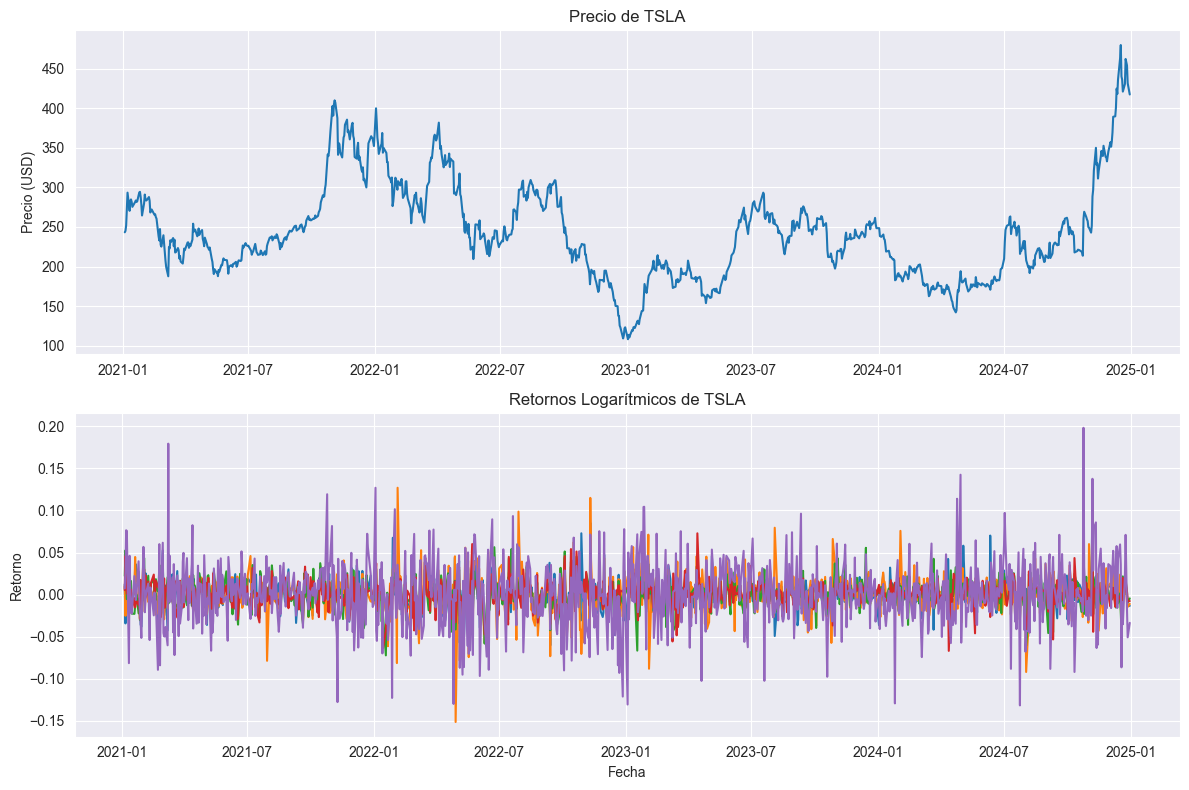

In [ ]:
# 1.1c) Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.
# Crear figura con 2 subplots
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Subplot 1: Serie de precios
ax[0].plot(df.index, df["TSLA"])
ax[0].set_title("Precio de TSLA")
ax[0].set_ylabel("Precio (USD)")
ax[0].grid(True)

# Subplot 2: Retornos logarítmicos
ax[1].plot(retornos_log.index, retornos_log)
ax[1].set_title("Retornos Logarítmicos de TSLA")
ax[1].set_ylabel("Retorno")
ax[1].set_xlabel("Fecha")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1.1d) ¿Qué diferencias observa entre los retornos simples y logarítmicos? ¿En qué escenarios es más conveniente usar retornos logarítmicos? Justifique su respuesta.
# El retorno logarítmico es para modelamiento financiero y el retorno simple es para descripción. El retorno logarítmico es acumulativo, considerando correctamente la suma en el tiempo. Es mayormente conveniente utilizar retornos logarítmicos para modelamiento financiero.

In [48]:
# Pregunta 1.2 — Retornos Multi-Período (9 puntos)
# Para el activo JPM:
# 1.2a) Calcule los retornos diarios, semanales y mensuales (simples y logarítmicos).
# Precio cierre JPM

p_cierre_JPM = yf.download('JPM', start='2021-01-01', end='2024-12-31', progress = False)['Close']

# Retorno diario simple / logarítimico
dayli_simple_return = p_cierre_JPM.pct_change().dropna()
print(dayli_simple_return)

Ticker           JPM
2021-01-05  0.005441
2021-01-06  0.046956
2021-01-07  0.032839
2021-01-08  0.001104
2021-01-11  0.014924
...              ...
2024-12-23  0.003325
2024-12-24  0.016444
2024-12-26  0.003425
2024-12-27 -0.008102
2024-12-30 -0.007671

[1003 rows x 1 columns]


In [51]:
dayli_log_return = np.log(p_cierre_JPM / p_cierre_JPM.shift(1)).dropna()
print(dayli_log_return)

Ticker           JPM
2021-01-05  0.005427
2021-01-06  0.045887
2021-01-07  0.032312
2021-01-08  0.001103
2021-01-11  0.014814
...              ...
2024-12-23  0.003319
2024-12-24  0.016310
2024-12-26  0.003420
2024-12-27 -0.008135
2024-12-30 -0.007700

[1003 rows x 1 columns]


In [60]:
# Retornos semanales
weekly_prices = p_cierre_JPM.resample('W').last()
weekly_simple_return = weekly_prices.pct_change().dropna()
weekly_log_return = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

print(weekly_log_return)
print(weekly_simple_return)


Ticker           JPM
2021-01-17  0.019079
2021-01-24 -0.035609
2021-01-31 -0.039020
2021-02-07  0.069858
2021-02-14  0.023423
...              ...
2024-12-08 -0.009496
2024-12-15 -0.030456
2024-12-22 -0.009800
2024-12-29  0.014913
2025-01-05 -0.007700

[208 rows x 1 columns]
Ticker           JPM
2021-01-17  0.019262
2021-01-24 -0.034983
2021-01-31 -0.038269
2021-02-07  0.072356
2021-02-14  0.023699
...              ...
2024-12-08 -0.009451
2024-12-15 -0.029997
2024-12-22 -0.009752
2024-12-29  0.015025
2025-01-05 -0.007671

[208 rows x 1 columns]


In [68]:
# Retornos mensuales
monthly_prices = p_cierre_JPM.resample('ME').last()
monthly_simple_return = monthly_prices.pct_change()
monthly_log_return = np.log(monthly_prices / monthly_prices.shift(1))

print(monthly_simple_return)
print(monthly_log_return)

Ticker           JPM
2021-01-31       NaN
2021-02-28  0.143779
2021-03-31  0.034382
2021-04-30  0.016330
2021-05-31  0.067811
2021-06-30 -0.052971
2021-07-31 -0.018550
2021-08-31  0.053827
2021-09-30  0.023382
2021-10-31  0.044130
2021-11-30 -0.065101
2021-12-31 -0.003022
2022-01-31 -0.055948
2022-02-28 -0.045760
2022-03-31 -0.038646
2022-04-30 -0.117923
2022-05-31  0.107825
2022-06-30 -0.148378
2022-07-31  0.033482
2022-08-31 -0.014130
2022-09-30 -0.081157
2022-10-31  0.215371
2022-11-30  0.097712
2022-12-31 -0.029527
2023-01-31  0.051408
2023-02-28  0.024221
2023-03-31 -0.090966
2023-04-30  0.069180
2023-05-31 -0.018301
2023-06-30  0.071697
2023-07-31  0.093542
2023-08-31 -0.073626
2023-09-30 -0.008952
2023-10-31 -0.034023
2023-11-30  0.122393
2023-12-31  0.089826
2024-01-31  0.031365
2024-02-29  0.067102
2024-03-31  0.076534
2024-04-30 -0.037152
2024-05-31  0.056796
2024-06-30 -0.001826
2024-07-31  0.057941
2024-08-31  0.056391
2024-09-30 -0.062011
2024-10-31  0.058901
2024-11-30  0

In [71]:
# 1.2b) Calcule el retorno acumulado a rolling 20 días usando retornos logarítmicos (recuerde la propiedad de aditividad)

rollinng_20d_log_return = np.log(p_cierre_JPM / p_cierre_JPM.shift(5)).dropna()
print(rollinng_20d_log_return)

Ticker           JPM
2021-01-11  0.099542
2021-01-12  0.109712
2021-01-13  0.064752
2021-01-14  0.038266
2021-01-15  0.019079
...              ...
2024-12-23 -0.004979
2024-12-24  0.016436
2024-12-26  0.053951
2024-12-27  0.034635
2024-12-30  0.007213

[999 rows x 1 columns]


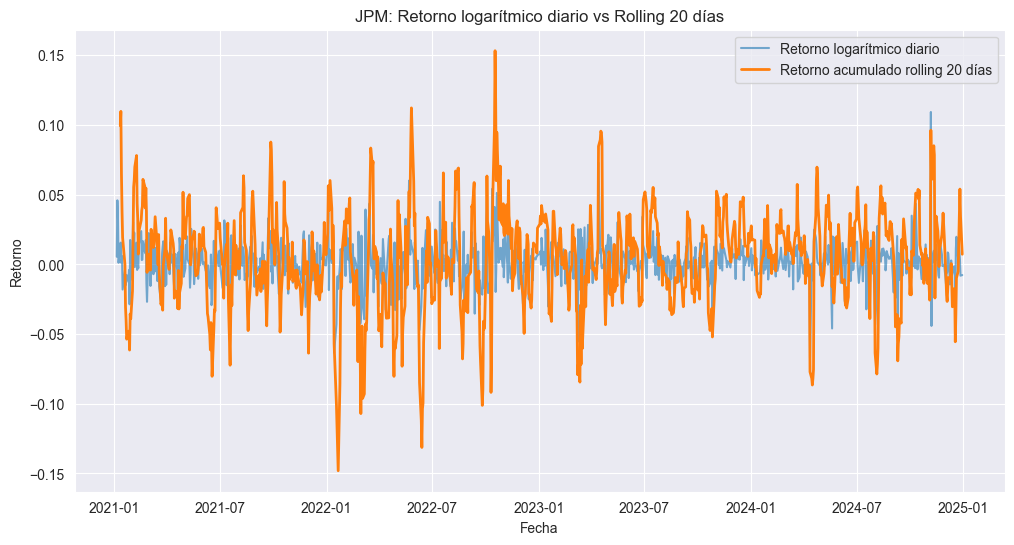

In [ ]:
# 1.2c) Visualice en un solo gráfico el retorno logarítimico diario y el retorno rolling de 20 días para JPM.


plt.figure(figsize=(12,6))

plt.plot(dayli_log_return.index, dayli_log_return,
         label='Retorno logarítmico diario',
         alpha=0.6)

plt.plot(rollinng_20d_log_return.index, rollinng_20d_log_return,
         label='Retorno acumulado rolling 20 días',
         linewidth=2)

plt.title('JPM: Retorno logarítmico diario vs Rolling 20 días')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.legend()
plt.grid(True)

plt.show()

In [80]:
# 1.2d) Calcule la media, desviación estándar, asimetría (skewness) y curtosis para los retornos diarios de cada frecuencia (diario, semanal, mensual). Presente los resultados en un DataFrame resumen.

resumen = pd.DataFrame({
    "Media": [
        dayli_log_return["JPM"].mean(),
        weekly_log_return["JPM"].mean(),
        monthly_log_return["JPM"].mean()
    ],
    "Desv. Estándar": [
        dayli_log_return["JPM"].std(),
        weekly_log_return["JPM"].std(),
        monthly_log_return  ["JPM"].std()
    ],
    "Asimetría": [
        dayli_log_return["JPM"].skew(),
        weekly_log_return["JPM"].skew(),
        monthly_log_return["JPM"].skew()
    ],
    "Curtosis": [
        dayli_log_return["JPM"].kurtosis(),
        weekly_log_return["JPM"].kurtosis(),
        monthly_log_return["JPM"].kurtosis()
    ]
},
index=["Diario", "Semanal", "Mensual"])

print(resumen.round(4))

          Media  Desv. Estándar  Asimetría  Curtosis
Diario   0.0007          0.0152     0.1866    4.4023
Semanal  0.0032          0.0338    -0.2277    0.6628
Mensual  0.0154          0.0727    -0.0988   -0.0712


In [81]:
print(retornos_simples)

Ticker          AAPL      AMZN        GS       JPM      TSLA
2021-01-05  0.012364  0.010004  0.022377  0.005441  0.007317
2021-01-06 -0.033661 -0.024897  0.053962  0.046956  0.028390
2021-01-07  0.034123  0.007577  0.021362  0.032839  0.079447
2021-01-08  0.008631  0.006496 -0.005383  0.001104  0.078403
2021-01-11 -0.023249 -0.021519  0.012927  0.014924 -0.078214
...              ...       ...       ...       ...       ...
2024-12-23  0.003065  0.000622  0.008267  0.003325  0.022657
2024-12-24  0.011478  0.017729  0.021041  0.016444  0.073572
2024-12-26  0.003175 -0.008732 -0.002677  0.003425 -0.017630
2024-12-27 -0.013242 -0.014534 -0.008688 -0.008102 -0.049479
2024-12-30 -0.013263 -0.010950 -0.004565 -0.007671 -0.033012

[1003 rows x 5 columns]


In [ ]:
# Pregunta 1.3 — Estandarización y Normalización (8 puntos)
# 1.3a) Tome los retornos diarios simples del portafolio completo (5 activos). Aplique estandarización (Standard Scaler) y normalización (Min-Max Scaler) a cada serie de retornos.

# Normalización (Min-Max Scaling)
scaler = MinMaxScaler()
X_scaled_minmax = scaler.fit_transform(retornos_simples.values.reshape(-1, 1))

# Estandarización (Scandard Scaling)
scaler = StandardScaler()
X_scaled_standard = scaler.fit_transform(retornos_simples.values.reshape(-1, 1))

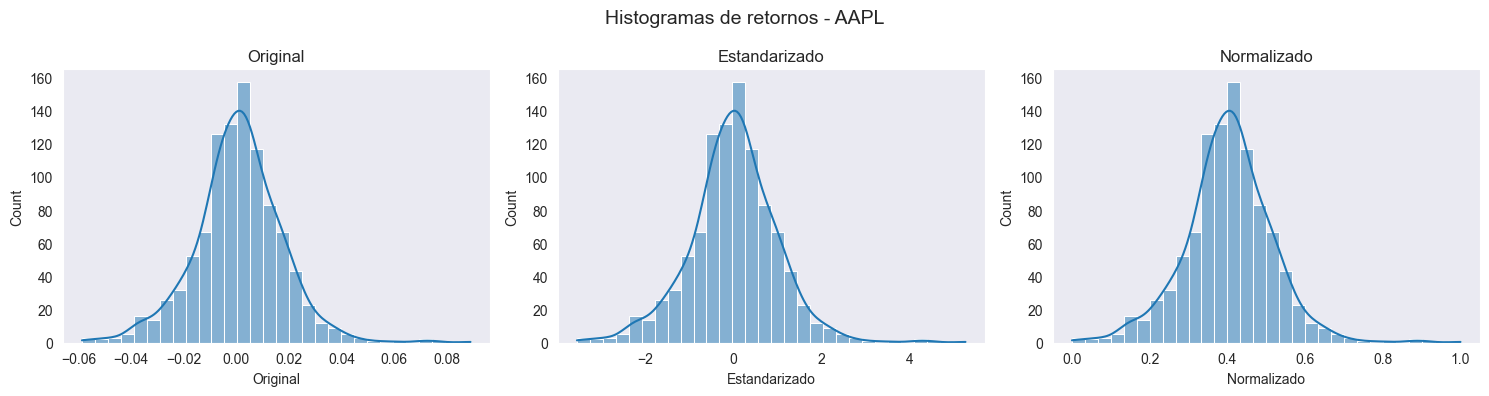

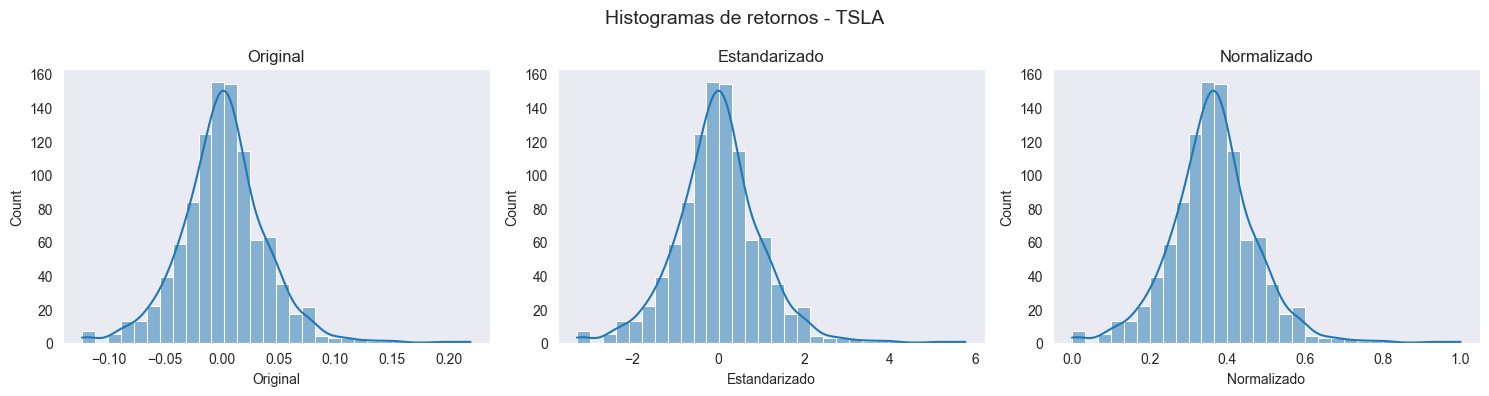

In [93]:
# 1.3b) Para los activos AAPL y TSLA, grafique en un panel de 3 columnas (original, estandarizado, normalizado) los histogramas de retornos.

for ticker in ['AAPL', 'TSLA']:

    retornos = returns[ticker].dropna().values.reshape(-1, 1)

    # Transformaciones
    scaler_std = StandardScaler()
    scaler_mm = MinMaxScaler()

    retornos_std = scaler_std.fit_transform(retornos)
    retornos_mm = scaler_mm.fit_transform(retornos)

    # DataFrame para graficar
    df_plot = pd.DataFrame({
        'Original': retornos.ravel(),
        'Estandarizado': retornos_std.ravel(),
        'Normalizado': retornos_mm.ravel()
    })

    # Gráficos
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, df_plot.columns):
        sns.histplot(df_plot[col], bins=30, kde=True, ax=ax)
        ax.set_title(col)

    fig.suptitle(f'Histogramas de retornos - {ticker}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# 1.3c) ¿Cuál de las dos transformaciones es más adecuada para comparar la volatilidad relativa entre los activos del portafolio? Justifique.

# Para comparar volatilidad relativa entre los activos del portafolio, la estandarización es la opción mas adecuada, ya que permite evaluar las fluctuaciones de los retornos usando la desviación estandar de cada serie.

In [97]:
# Parte II: Análisis de Relaciones y Estructura de Riesgo (25 puntos)
# Pregunta 2.1 — Matrices de Correlación (10 puntos)

# 2.1a Calcule las matrices de correlación de Pearson, Spearman y Kendall para los 5 activos. 
# Correlación de Pearson
corr_pearson = retornos_simples.corr(method='pearson')

# Correlación de Spearman
corr_spearman = retornos_simples.corr(method='spearman')

# Correlación de Kendall
corr_kendall = retornos_simples.corr(method='kendall')

print("Pearson")
print(corr_pearson)

print("\nSpearman")
print(corr_spearman)

print("\nKendall")
print(corr_kendall)


Pearson
Ticker      AAPL      AMZN        GS       JPM      TSLA
Ticker                                                  
AAPL    1.000000  0.562226  0.332048  0.294702  0.492028
AMZN    0.562226  1.000000  0.359423  0.295769  0.427575
GS      0.332048  0.359423  1.000000  0.763537  0.287263
JPM     0.294702  0.295769  0.763537  1.000000  0.261380
TSLA    0.492028  0.427575  0.287263  0.261380  1.000000

Spearman
Ticker      AAPL      AMZN        GS       JPM      TSLA
Ticker                                                  
AAPL    1.000000  0.595981  0.332771  0.292710  0.503427
AMZN    0.595981  1.000000  0.331142  0.272547  0.458631
GS      0.332771  0.331142  1.000000  0.745473  0.302989
JPM     0.292710  0.272547  0.745473  1.000000  0.275204
TSLA    0.503427  0.458631  0.302989  0.275204  1.000000

Kendall
Ticker      AAPL      AMZN        GS       JPM      TSLA
Ticker                                                  
AAPL    1.000000  0.431520  0.230988  0.204103  0.352102
AMZN

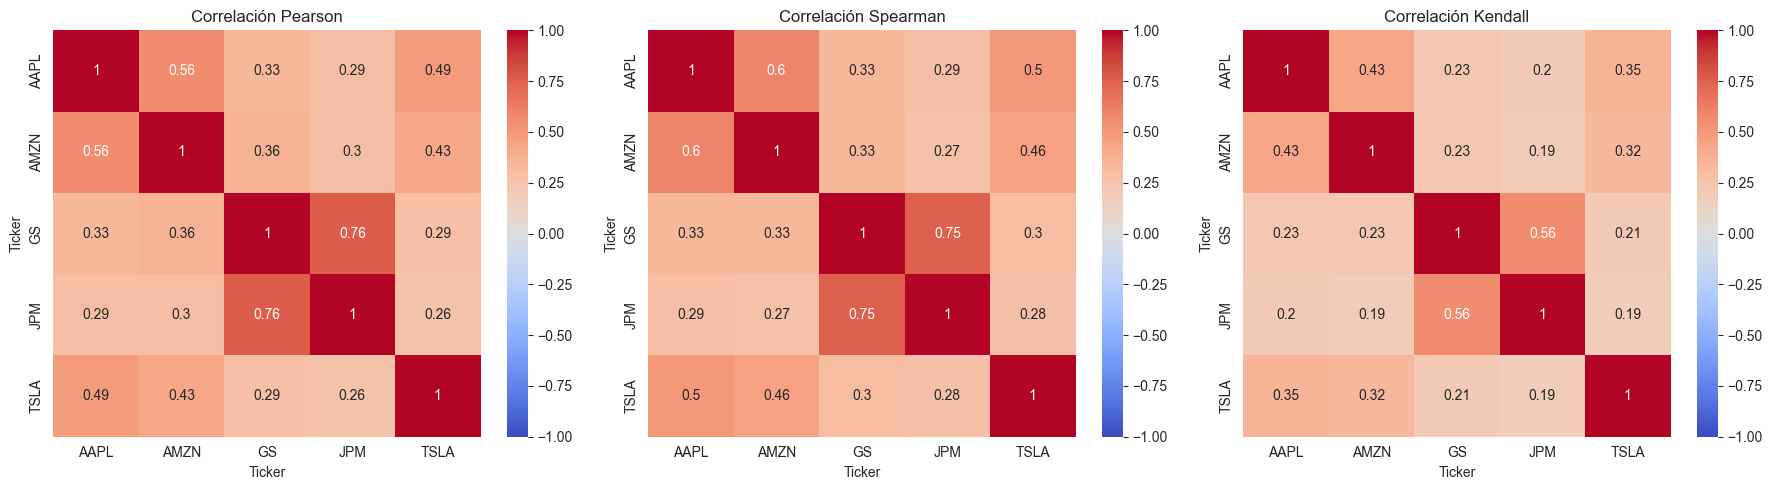

In [98]:
# 2.1b Visualice las tres matrices en un panel de 3 heatmaps con anotaciones numéricas.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title('Correlación Pearson')

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title('Correlación Spearman')

sns.heatmap(
    corr_kendall,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=axes[2]
)
axes[2].set_title('Correlación Kendall')

plt.tight_layout()
plt.show()

In [99]:
# 2.1c Identifique el par de activos con mayor y menor correlación de Pearson.

# Eliminar la diagonal (correlación consigo mismo)
corr_aux = corr_pearson.copy()

np.fill_diagonal(corr_aux.values, np.nan)

# Mayor correlación
mayor = corr_aux.unstack().idxmax()
valor_mayor = corr_aux.unstack().max()

# Menor correlación
menor = corr_aux.unstack().idxmin()
valor_menor = corr_aux.unstack().min()

print("Mayor correlación:")
print(mayor, "=", round(valor_mayor, 4))

print("\nMenor correlación:")
print(menor, "=", round(valor_menor, 4))

ValueError: underlying array is read-only

In [ ]:
# 2.1d Compare los resultados entre Pearson y Spearman. ¿Existen diferencias relevantes? ¿A qué se pueden deber estas diferencias en el contexto de retornos financieros?



In [137]:
# Pregunta 2.2 — Matriz de Covarianza (8 puntos)
# 2.2a) Calcule la matriz de varianzas y covarianzas  para los retornos mensuales del portafolio.
# Matriz de varianzas y covarianzas

monthly_return_simples5A = df.pct_change().dropna()
matriz_cov = monthly_return_simples5A.cov()
print(matriz_cov)

Ticker      AAPL      AMZN        GS       JPM      TSLA
Ticker                                                  
AAPL    0.000281  0.000210  0.000092  0.000075  0.000312
AMZN    0.000210  0.000495  0.000132  0.000100  0.000360
GS      0.000092  0.000132  0.000274  0.000192  0.000180
JPM     0.000075  0.000100  0.000192  0.000231  0.000150
TSLA    0.000312  0.000360  0.000180  0.000150  0.001432


In [142]:
# 2.2b) Verifique que es semidefinida positiva calculando sus valores propios (eigenvalues) e imprimiéndolos. ¿Qué condición deben cumplir?
# Valores propios
eigenvalues = np.linalg.eigvals(matriz_cov)

print("Valores propios:")
print(eigenvalues)

Valores propios:
[1.72082985e-03 4.79880167e-04 3.08621269e-04 1.44547036e-04
 5.87174654e-05]


In [141]:
if np.all(eigenvalues >= -1e-10):
    print("La matriz es semidefinida positiva.")
else:
    print("La matriz NO es semidefinida positiva.")

La matriz es semidefinida positiva.


In [143]:
# 2.2c) A partir de la sumatoria, calcule la volatilidad anualizada de cada activo.

varianzas_mensuales = np.diag(matriz_cov)
vol_mensual = np.sqrt(varianzas_mensuales)

# Varianzas mensuales (diagonal de la matriz de covarianza)
varianzas_mensuales = np.diag(matriz_cov)

# Volatilidad mensual
vol_mensual = np.sqrt(varianzas_mensuales)

# Volatilidad anualizada
vol_anual = vol_mensual * np.sqrt(12)

# Mostrar resultados
vol_anual = pd.Series(
    vol_anual,
    index=matriz_cov.columns,
    name='Volatilidad Anualizada'
)

print(vol_anual)

Ticker
AAPL    0.058062
AMZN    0.077044
GS      0.057303
JPM     0.052702
TSLA    0.131085
Name: Volatilidad Anualizada, dtype: float64


In [144]:
# 2.2d) Según la covarianza, ¿qué par de activos ofrece mejor diversificación? Justifique.

print(matriz_cov)


Ticker      AAPL      AMZN        GS       JPM      TSLA
Ticker                                                  
AAPL    0.000281  0.000210  0.000092  0.000075  0.000312
AMZN    0.000210  0.000495  0.000132  0.000100  0.000360
GS      0.000092  0.000132  0.000274  0.000192  0.000180
JPM     0.000075  0.000100  0.000192  0.000231  0.000150
TSLA    0.000312  0.000360  0.000180  0.000150  0.001432


In [145]:
cov_aux = matriz_cov.mask(np.eye(len(matriz_cov), dtype=bool))

par_mejor = cov_aux.unstack().idxmin()
cov_min = cov_aux.unstack().min()

print(par_mejor)
print(cov_min)

('AAPL', 'JPM')
7.514784539124109e-05


In [ ]:
# El par de activos que ofrece la mejor diversificación son (AAPL, JPM) ya que presentan la menor covarianza del portafolio. Esto indica que sus retornos tienen la menor tendencia a moverse en una misma dirección (correlación).

In [146]:
# Pregunta 2.3 — Correlaciones Rodantes (Rolling Correlation) (7 puntos)
# 2.3a) Calcule la correlación de Pearson rolling de 60 días entre los retornos de AAPL y JPM.

corr_rolling_60 = (
    retornos_simples['AAPL']
    .rolling(window=60)
    .corr(retornos_simples['JPM'])
)

print(corr_rolling_60.tail())


2024-12-23   -0.018523
2024-12-24   -0.007480
2024-12-26   -0.061700
2024-12-27   -0.046707
2024-12-30   -0.040370
dtype: float64


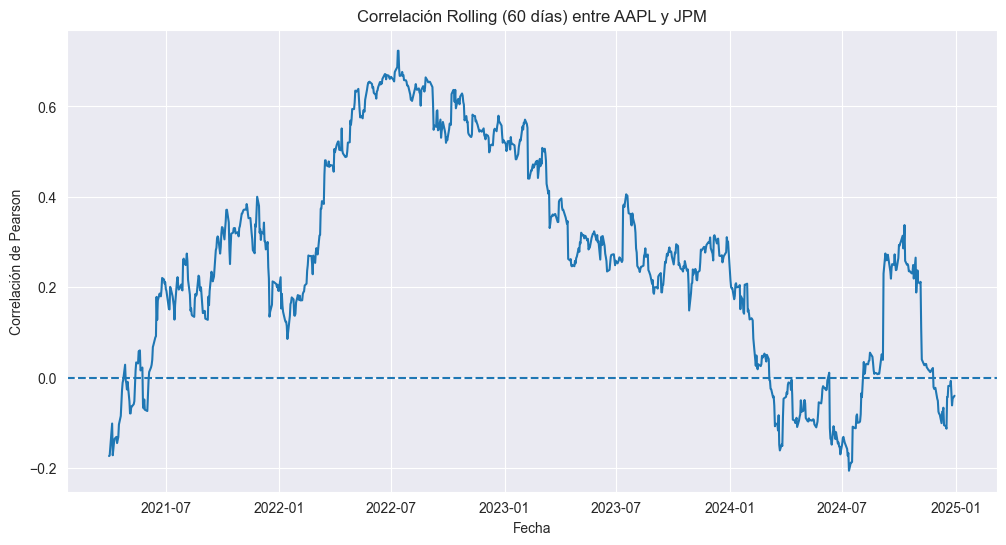

In [150]:
# 2.3b) Grafique esta correlación rodante en el tiempo, marcando con una línea horizontal la correlación promedio del período.

plt.figure(figsize=(12, 6))
plt.plot(corr_rolling_60)

plt.title('Correlación Rolling (60 días) entre AAPL y JPM')
plt.xlabel('Fecha')
plt.ylabel('Correlación de Pearson')

plt.axhline(y=0, linestyle='--')

plt.grid(True)
plt.show()




In [ ]:
# 2.3c) Identifique visualmente en el gráfico al menos dos períodos en los que la correlación haya sido inusualmente alta o baja. Proponga una explicación financiera para cada uno (puede apoyarse en eventos de mercado conocidos del período 2021–2024).
# En el gráfico se observa un período de correlación excepcionalmente alta entre mayo y agosto de 2022, cuando la correlación alcanzó valores cercanos a 0.70. Este comportamiento puede asociarse al ciclo de aumentos de tasas de interés implementado por la Reserva Federal para combatir la inflación, lo que afectó simultáneamente a los sectores tecnológico y financiero, generando movimientos más sincronizados entre AAPL y JPM.
# Por otro lado, entre junio y julio de 2024 la correlación cayó hasta aproximadamente -0.20, constituyendo el nivel más bajo de la muestra. Una posible explicación es la divergencia entre los factores que impulsaban a ambos sectores: mientras las empresas tecnológicas se beneficiaban del optimismo relacionado con la inteligencia artificial, las entidades financieras estaban más expuestas a las expectativas sobre tasas de interés y condiciones crediticias. Esto provocó movimientos relativamente independientes entre ambos activos y redujo la correlación observada.

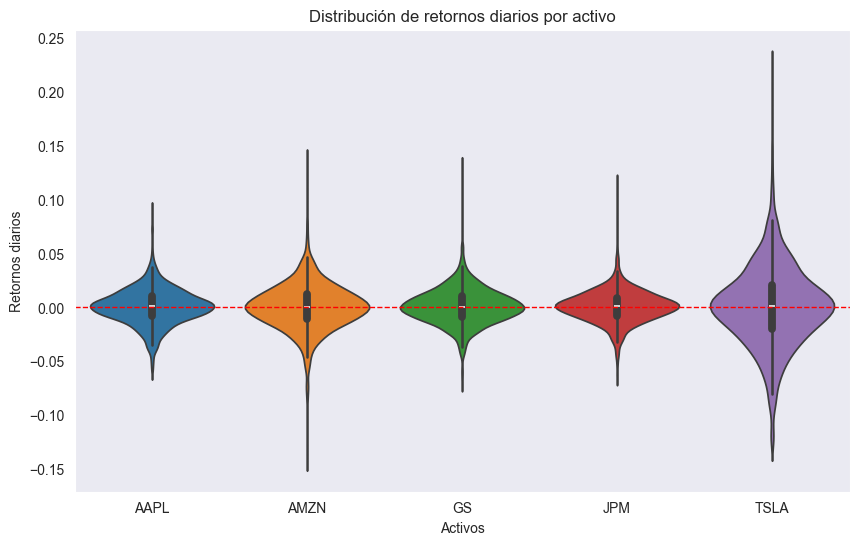

In [ ]:
# Parte III: Comparación Estadística de Activos (20 puntos)
# Pregunta 3.1 - Visualización de Distribuciones (5 puntos)

# 3.1ab Genere un violin plot con los retornos diarios de los 5 activos del portafolio.

dayli_simple_return5A = df.pct_change().dropna()

plt.figure(figsize=(10, 6))

sns.violinplot(data=dayli_simple_return5A)

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title("Distribución de retornos diarios por activo")
plt.xlabel("Activos")
plt.ylabel("Retornos diarios")

plt.show()

In [ ]:
# 3.1c TSLA es el activo que presenta mayor dispersión de retornos. Se observa en la variabilidad/volatilidad de sus retornos, con una gráfico de amplia densidad el que se extiende desde -0,08 hasta +0,24 con una envergadura de 32 puntos base.
# La mayor distribución asimétrica la tiene GS (Goldman Sachs) quien muestra asimetría positiva.
# Desde un punto de vista de riesgo, el activo con mas riesgoso es TSLA ya que presenta mayor volatilidad expuesto por su mayor dispersión, a la vez que presenta posibilidad de pérdidas extremas.

In [169]:
# Pregunta 3.2 Tests de Igualdad de Medias (8 puntos)
# Queremos evaluar si los retornos promedio de los 5 activos son estadísticamente distintos entre sí.

# 3.2a Aplique el Test Anova (Ho: las medias son iguales) y el Test de Kruskal-Wallis (Ho: las medianas son iguales). Use nivel de significancia 0,05

# Anova (medias iguales)
anova_stat, anova_p = f_oneway(*[dayli_simple_return5A[col].dropna() for col in dayli_simple_return5A.columns])
print(anova_stat, anova_p)

0.11317917961247759 0.9779314378103617


In [168]:
# Kruskal-Wallis (medianas iguales)
kruskal_stat, kruskal_p = kruskal(*[dayli_simple_return5A[col].dropna() for col in dayli_simple_return5A.columns ])
print(kruskal_stat, kruskal_p)

In [170]:
# 3.2b Para el par de AAPL vs TSLA, aplique el Test de Mann-Whitney U y formule explícitamente las hipótesis Ho y H1.
# Ho (nula): AAPL y TSLA tienen la misma distribución (misma mediana / ubicación)
# H1 (alternativa): AAPL y TSLA tienen distribuciones diferentes

u_stat, u_p = mannwhitneyu(
    dayli_simple_return5A["AAPL"].dropna(),
    dayli_simple_return5A["TSLA"].dropna(),
    alternative="two-sided"
)

In [172]:
# 3.2c Presentación de resultados en DataFrame.

resultados = pd.DataFrame({
    "Test": ["Anova", "Kruskal-Wallis", "Mann-Whitney U (AAPL vs TSLA)"],
    "Estadístico": [anova_stat, kruskal_stat, u_stat],
    "p-valor": [anova_p, kruskal_p, u_p],
    "Decisión": [
        "Rechazar H0" if anova_p < 0.05 else "No rechazar H0",
        "Rechazar H0" if kruskal_p < 0.05 else "No rechazar H0",
        "Rechazar H0" if u_p < 0.05 else "No rechazar H0"
    ]
})

print(resultados)

                            Test    Estadístico   p-valor        Decisión
0                          Anova       0.113179  0.977931  No rechazar H0
1                 Kruskal-Wallis       0.205370  0.995075  No rechazar H0
2  Mann-Whitney U (AAPL vs TSLA)  503017.500000  0.999231  No rechazar H0


In [ ]:
# 3.2d ¿Coinciden los tests paramétricos y no paramétricos en sus conclusiones? ¿Cuándo es más apropiado usar los no paramétricos en el análisis de retornos financieros?
# Los tres tests estadísticos concuerdan en que no hay evidencia estadística de diferencias significativas entre los retornos de los activos analizados.
# En finanzas los tests no paramétricos suelen ser mas apropiados cuando no se cumplen los supuestos del modelo paramétrico. Colas pesadas, asimetría, outliers frecuentes.  

In [173]:
# Pregunta 3.3 Tests de Igualdad de Varianzas (7 puntos)
# 3.3a Aplique el Test de Levene y el Test de Bartlett para los 5 activos. Use significación al 5%.

levene_stat, levene_p = levene(*[dayli_simple_return5A[col] for col in dayli_simple_return5A.columns])

In [174]:
# Bartlett
bartlett_stat, bartlett_p = bartlett(*[dayli_simple_return5A[col] for col in dayli_simple_return5A.columns])

In [ ]:
# 3.3b Presente los resultados en un DataFrame resumen similar al de la pregunta anterior.

resultados_varianzas_ig = pd.DataFrame({
    "Test": ["Levene", "Bartlett"],
    "Estadístico": [levene_stat, bartlett_stat],
    "p-valor": [levene_p, bartlett_p],
    "Decisión": [
        "Rechazar H0" if levene_p < 0.05 else "No rechazar H0",
        "Rechazar H0" if bartlett_p < 0.05 else "No rechazar H0"
    ]

})

print(resultados_varianzas_ig)

       Test  Estadístico        p-valor     Decisión
0    Levene   185.435725  2.025105e-148  Rechazar H0
1  Bartlett  1318.326980  3.536593e-284  Rechazar H0


In [ ]:
# 3.3c Basándose en los resultados, ¿puede concluir que algún activo tiene una volatilidad significativamente distinta al resto? ¿Qué implicancias tiene esto para la construcción de un portafolio diversificado?
# Si, se concluye. Ambos tests rechazan H0, lo que implica que existe evidencia estadísticamente significativa que al menos un activo tiene una volatilidad distinta a los demás. En base al resultados de ambos tests, se concluye que no todos o ninguno comparte la misma varianza.
# La implicancia en un portafolio de riesgo es que al compartir distintas volatilidades y correlaciones, se asumen distintos niveles de riesgo, que es justamente lo que busca un portafolio diversificado. 

In [181]:
# 3.3d ¿Por qué puede existir diferencia entre los resultados de Levene y Bartlett? ¿Cuál es mas apropiado para datos financieros?
# Levene es el mas apropiado para modelamiento financiero ya que no depende de que los datos sean normales, es robusto a outliers y es mas estable en series de retornos normales. Las diferencias entre un test y otro se pueden dar precisamente por "la" o la "no normalidad" de los datos.


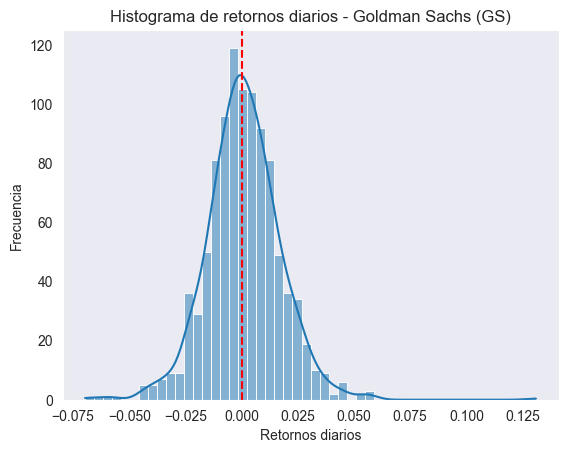

In [ ]:
# Parte IV: Distribuciones Muestrales y Teroema del Límite Central (20 puntos)
# Pregunta 4.1 Distribución Muestral del Retorno Promedio (10 puntos)
# 4.1a Grafique el histograma de los retornos diarios e indique visualmente si la distribución parece normal. Calcule la asimetría y curtosis de la distribución real.

gs_retornos = dayli_simple_return5A["GS"].dropna()

plt.Figure(figsize=(8,5))
sns.histplot(gs_retornos, bins=50, kde=True)

plt.title("Histograma de retornos diarios - Goldman Sachs (GS)")
plt.xlabel("Retornos diarios")
plt.ylabel("Frecuencia")

plt.axvline(0, color="red", linestyle="--")

plt.show()

In [189]:
# 4.1a Visualmente pareciera ser una distribución normal, aunque no perfecta ya que presenta colas mas pesadas que una normal y ligera asimetría. Visualmente se deduce no normalidad.
# 4.1a Calcular asimetría y curtosis de la distribución real.

from scipy.stats import skew, kurtosis

Asimetría = skew(gs_retornos)
Curtosis = kurtosis(gs_retornos, fisher=True)

print("Asimetría:", Asimetría)
print("Curtosis (exceso):", Curtosis)

Asimetría: 0.4208151738735142
Curtosis (exceso): 4.540065134029096
